# Linear Regression

\begin{equation}
y = a + bx
\end{equation}
$a$ is bias

$b$ is weights

In [1]:
import numpy as np
import torch

## make fake data

$$
2x + 1 + \mathrm{noise} = y
$$


In [2]:
np.random.seed(42)
x = np.random.rand(100, 1) #make random vector with size 100
y = 1 + (2 * x) + .1 * np.random.randn(100, 1) #make y depends on x with noise by equation y = 1 + 2 * x + (noise)

In [4]:
x.shape, y.shape

((100, 1), (100, 1))

In [5]:
# Shuffles the indices
idx = np.arange(100)
np.random.shuffle(idx)

In [6]:
idx

array([76, 83, 80, 98,  2, 77, 71, 84, 89, 50, 40, 51, 67, 86, 37, 49,  4,
       10, 69, 81,  9, 54, 55, 87, 64, 44, 90, 75, 33, 30, 93, 95, 14, 61,
       11, 13, 15,  7,  0, 19, 35,  6, 12, 65, 70, 88, 56, 58, 28, 38, 91,
       42,  8, 73, 39, 85, 25, 92, 41, 26,  1, 22, 21, 46, 74, 79, 78, 72,
       57, 53, 24, 17, 66, 32, 31, 62, 59, 52, 82, 23, 36,  5, 45, 99, 43,
       16, 48, 94, 34,  3, 18, 47, 60, 68, 63, 27, 96, 29, 20, 97])

In [7]:
# Uses first 80 random indices for train
train_idx = idx[:80]
# Uses the remaining indices for validation
val_idx = idx[80:]

# Generates train and validation sets
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

In [10]:
x_train.shape, y_train.shape

((80, 1), (80, 1))

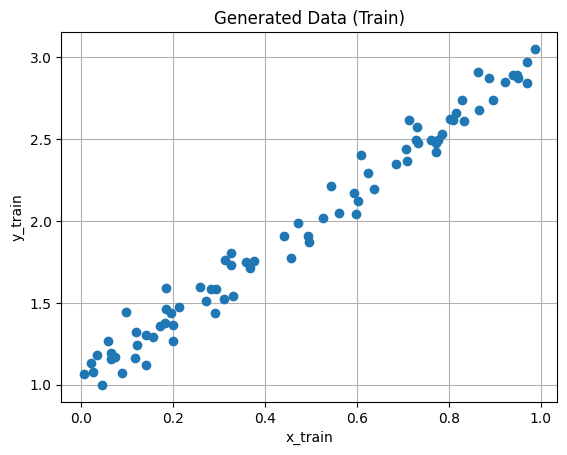

In [12]:
import matplotlib.pyplot as plt

plt.plot(x_train, y_train, 'o')
plt.title('Generated Data (Train)')
plt.grid()
plt.xlabel('x_train')
plt.ylabel('y_train');

## gradient descent

we calculate loss and then by gradient we update our parameters

we want find $a$ and $b$

### init parameters

In [14]:
np.random.seed(42)
a = np.random.randn(1)
b = np.random.randn(1)
print(a, b)

# Computes our model's predicted output
# y = bx + a
y = a + b * x_train
print(y.shape)

[0.49671415] [-0.1382643]
(80, 1)


### loss function

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} \left(y_i - (a + b x_i)\right)^2
$$


In [15]:
error = (y_train - y)
loss = (error ** 2).mean()
print(loss)

2.7421577700550976


### gradient

$$
\frac{\partial \mathrm{MSE}}{\partial a}
=
\frac{\partial \mathrm{MSE}}{\partial \hat{y}_i}
\cdot
\frac{\partial \hat{y}_i}{\partial a}
=
\cdots
=
-\frac{2}{N}
\sum_{i=1}^{N}
(y_i - \hat{y}_i)
$$

$$
\frac{\partial \mathrm{MSE}}{\partial b}
=
\frac{\partial \mathrm{MSE}}{\partial \hat{y}_i}
\cdot
\frac{\partial \hat{y}_i}{\partial b}
=
\cdots
=
-\frac{2}{N}
\sum_{i=1}^{N}
x_i (y_i - \hat{y}_i)
$$


In [16]:
# Computes gradients for both "a" and "b" parameters
a_grad = -2 * error.mean()
b_grad = -2 * (x_train * error).mean()
print('a_grad: ', a_grad)
print('b_grad: ', b_grad)

a_grad:  -3.044811379650508
b_grad:  -1.8337537171510832


### update parameters

$$
a = a - \mu \frac{\partial \mathrm{MSE}}{\partial a}
$$

$$
b = b - \mu \frac{\partial \mathrm{MSE}}{\partial b}
$$


### Do it for 1000 epochs

In [17]:
# Initializes parameters "a" and "b" randomly
np.random.seed(42)
a = np.random.randn(1)
b = np.random.randn(1)
print('Initial value of a: ', a)
print('Initial value of b: ', b)
# Sets learning rate
lr = 1e-1
# Defines number of epochs
n_epochs = 1000
for epoch in range(n_epochs):
    # Computes our model's predicted output
    yhat = a + b * x_train

    # How wrong is our model? That's the error!
    error = (y_train - yhat)
    # It is a regression, so it computes mean squared error (MSE)
    loss = (error ** 2).mean()

    # Computes gradients for both "a" and "b" parameters
    a_grad = -2 * error.mean()
    b_grad = -2 * (x_train * error).mean()

    # Updates parameters using gradients and the learning rate
    a = a - lr * a_grad
    b = b - lr * b_grad

print('Final value of a: ', a)
print('Final value of b: ', b)
print('Final Error : ',(((a + b * x_train) - y_train)**2).mean())

Initial value of a:  [0.49671415]
Initial value of b:  [-0.1382643]
Final value of a:  [1.02354094]
Final value of b:  [1.96896411]
Final Error :  0.008044657695505126


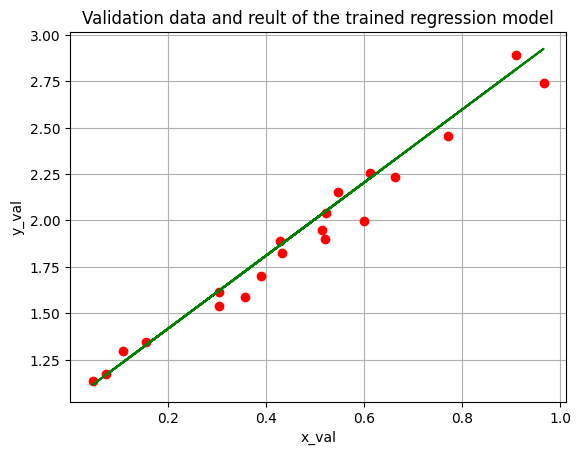

In [19]:
plt.plot(x_val, y_val, 'ro')
plt.title('Validation data and reult of the trained regression model')
plt.grid()
plt.xlabel('x_val')
plt.ylabel('y_val')
# Final regression model
yhat = a + b * x_val
plt.plot(x_val, yhat, 'g');

### make life easier by pytorch !!!

In [20]:
# tensor
tensor = torch.tensor([[[1, 2, 8, 2],
               [3, 0, 9, 9],
               [7, 2, 0, 6]],
              [[0, 9, 8, 2],
               [1, 8, 5, 5],
               [2, 8, 1, 7]]])

tensor

tensor([[[1, 2, 8, 2],
         [3, 0, 9, 9],
         [7, 2, 0, 6]],

        [[0, 9, 8, 2],
         [1, 8, 5, 5],
         [2, 8, 1, 7]]])

In [22]:
tensor.shape

torch.Size([2, 3, 4])

In [23]:
type(tensor)

torch.Tensor

In [24]:
# torch.tensor([[[1, 2, 8, 2],
#                [3, 0, 9, 9],
#                [7, 2, 0, 6]],
#               [[0, 9, 8, 2],
#                [1, 8, 5, 5],
#                [2, 8, 1, 7]]], device=torch.device('cuda:0'))

# tensor.shape

In [25]:
torch.cuda.is_available()

False

In [26]:
#torch.cuda.get_device_properties('cuda:0')

In [27]:
#convert numpy array to tensor and
np_array = np.random.randint(0, 10, (2, 3))
print(np_array)
print(50*'-')
tensor = torch.from_numpy(np_array)
print(tensor)

[[7 4 6]
 [9 2 6]]
--------------------------------------------------
tensor([[7, 4, 6],
        [9, 2, 6]], dtype=torch.int32)


In [28]:
#convert tensor  to numpy array
tensor = torch.from_numpy(np_array)
print(tensor)
print(50*'-')
np_array = tensor.numpy()
print(np_array)

tensor([[7, 4, 6],
        [9, 2, 6]], dtype=torch.int32)
--------------------------------------------------
[[7 4 6]
 [9 2 6]]


In [29]:
# TypeError: can't convert CUDA tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.
# a = torch.randint(10, (2, 3), device=torch.device('cuda'))
# print(a)
# print(50*'-')
# # Method 1
# b = a.to('cpu').numpy()
# print(b)
# print(50*'-')
# # Method 2
# c = a.cpu().numpy()
# print(c)